<a href="https://colab.research.google.com/github/cl2832/CHEME-5660-CourseRepository-Fall-2025/blob/main/GTG_performance/CHP_IAC_OLS_vs_GBT_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CHP Causal Regression — OLS vs GBT Total-Effect Comparison
## Cornell Combined Heat and Power Plant
### Power & Fuel outcomes × OLS/GBT × Spec A/B × Plugin + AIPW

**Pipeline**: Load → CONFIG → Prepare → OLS baseline (original) → **New Section 7**: Fair OLS-vs-GBT comparison with day-block split, dual outcomes, AIPW


---
## 1. Setup

In [1]:
# ============================================================================
# INSTALL LIGHTGBM (required for GBT section)
# ============================================================================
!pip install -q lightgbm


In [2]:
# ============================================================================
# ALL IMPORTS (single cell, no duplicates)
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from pathlib import Path
import warnings, os, sys, time
warnings.filterwarnings('ignore')

import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrix, bs
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMRegressor

SEED = 42
np.random.seed(SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 5),
                     'axes.grid': True, 'grid.alpha': 0.3})
print('All imports done (incl. LightGBM, LogisticRegression)')


All imports done (incl. LightGBM, LogisticRegression)


---
## 2. Load Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted


In [4]:
from google.colab import userdata
!rm -rf /content/insight-chp
token = userdata.get('GITHUB_TOKEN')
!git clone https://{token}@github.com/cl2832/insight-chp.git /content/insight-chp
sys.path.insert(0, '/content/insight-chp/GTG_performance')
from src.chp_preprocessing import load_and_preprocess
print('Import successful')


Cloning into '/content/insight-chp'...
remote: Enumerating objects: 336, done.
remote: Counting objects: 100% (138/138), done.
remote: Compressing objects: 100% (131/131), done.
remote: Total 336 (delta 82), reused 20 (delta 6), pack-reused 198 (from 1)
Receiving objects: 100% (336/336), 12.60 MiB | 13.18 MiB/s, done.
Resolving deltas: 100% (187/187), done.
Import successful


In [5]:
results = load_and_preprocess(
    data_path='/content/drive/MyDrive/M.Eng._Project/Data/chp_raw_data/'
              'merged_chp_data_jul2025_canonical.xlsx',
    cache_dir='/content/drive/MyDrive/M.Eng._Project/Data/chp_raw_data',
    power_threshold_mw=11.0,
    filtering_mode='manual',
    show_plots=False,
    cooling_mode='binary',
)

df      = results['df']
df_ct1  = results['df_ct1']
df_ct2  = results['df_ct2']
df_both = results['df_both']
print(f'df_ct1: {len(df_ct1):,}  |  df_ct2: {len(df_ct2):,}')

# Quick check for fuel column
for ct_p in ['ct1', 'ct2']:
    fuel_col = f'{ct_p}_gas_fuel_flow_lbph'
    has_it = fuel_col in df_ct1.columns or fuel_col in df_ct2.columns
    print(f'  {fuel_col}: {"FOUND" if has_it else "NOT FOUND"}')


📦 Loading from CACHE: /content/drive/MyDrive/M.Eng._Project/Data/chp_raw_data/merged_chp_data_jul2025_canonical.pkl
   ✅ 44,688 rows × 90 columns

CALCULATING PERFORMANCE METRICS

📊 CT1 Metrics:
   ✓ ct1_power_mw
   ✓ ct1_heat_input_mmbtu_h
   ✓ ct1_efficiency_pct (avg: 25.65%, 44,176 valid)

📊 CT2 Metrics:
   ✓ ct2_power_mw
   ✓ ct2_heat_input_mmbtu_h
   ✓ ct2_efficiency_pct (avg: 31.02%, 44,623 valid)

❄️  IAC Status:
   ✓ cooling_on  (BINARY mode, threshold: 50.0 GPM)
     • Flow range: -2.9 – 1172.7 GPM
     • ON:  20,476 records
     • OFF: 24,212 records

OPERATIONAL STATUS SUMMARY
Threshold: 11.0 MW

CT1:  Operating 35,820 (80.2%)  |  Offline 8,868 (19.8%)
CT2:  Operating 44,612 (99.8%)  |  Offline 76 (0.2%)

Combined:
  Both ON:   35,804  (80.1%)
  CT1 only:  16  (0.0%)
  CT2 only:  8,808  (19.7%)
  Both OFF:  60  (0.1%)

SMART FILTERING (INDEPENDENT CT1 & CT2)

🎯 MANUAL MODE: fixed thresholds
   CT1: > 11.0 MW
   CT2: > 11.0 MW

📊 Filtering Results:
  Original:      44,688 rec

---
## 3. CONFIG
Single source of truth for all parameters.

In [6]:
# ============================================================================
# NESTED CONFIG (original + new comparison section)
# ============================================================================
CONFIG = {
    'data': {
        'train_temp_range_F':  (55, 110),
        'report_temp_range_F': (55, 110),
    },
    'treatment': {
        'method':           'full_vs_off',
        'switch_window_min': 10,
    },
    'model': {
        'spec': 'A',
    },
    'overlap': {
        'enabled':          True,
        'strategy':         'strong_grid',
        'temp_bin_width_F': 2.5,
        'strong_min':       50,
        'weak_min':         20,
        'min_total':        50,
        'on_rate_lo':       0.10,
        'on_rate_hi':       0.90,
    },
    'bootstrap': {
        'n_iterations':  50,
        'ci_level':      0.95,
    },
    'diagnostics': {
        'enabled':              True,
        'binned_diff_width_F':  2,
        'test_days_frac':       0.2,
        'jackknife_enabled':    True,
        'jackknife_max_days':   40,
    },
    # --- NEW: comparison section ---
    'compare': {
        'test_days_frac':  0.20,
        'boot_n':          500,
        'boot_ci':         0.95,
        'propensity_clip': (0.02, 0.98),
        'lgbm_params': {
            'n_estimators': 300,
            'learning_rate': 0.05,
            'max_depth': 6,
            'num_leaves': 31,
            'min_child_samples': 30,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'random_state': 42,
            'n_jobs': -1,
            'verbose': -1,
        },
    },
    'seed':       42,
    'output_dir': './outputs',
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)
np.random.seed(CONFIG['seed'])

def _pp(d, indent=0):
    for k, v in d.items():
        if isinstance(v, dict):
            print(' '*indent + f'{k}:')
            _pp(v, indent+4)
        else:
            print(' '*indent + f'{k:25s} = {v}')

print('CONFIG:'); _pp(CONFIG)


CONFIG:
data:
    train_temp_range_F        = (55, 110)
    report_temp_range_F       = (55, 110)
treatment:
    method                    = full_vs_off
    switch_window_min         = 10
model:
    spec                      = A
overlap:
    enabled                   = True
    strategy                  = strong_grid
    temp_bin_width_F          = 2.5
    strong_min                = 50
    weak_min                  = 20
    min_total                 = 50
    on_rate_lo                = 0.1
    on_rate_hi                = 0.9
bootstrap:
    n_iterations              = 50
    ci_level                  = 0.95
diagnostics:
    enabled                   = True
    binned_diff_width_F       = 2
    test_days_frac            = 0.2
    jackknife_enabled         = True
    jackknife_max_days        = 40
compare:
    test_days_frac            = 0.2
    boot_n                    = 500
    boot_ci                   = 0.95
    propensity_clip           = (0.02, 0.98)
    lgbm_params:
        n_est

---
## 4. Core Helper Functions
All functions defined before first use.

### 4a. Data Preparation (treatment + decontaminate + filter)

In [7]:
# ============================================================================
# prepare_df: treatment assignment + decontamination + temp filter + time cols
# ============================================================================

def assign_treatment(df, method='full_vs_off'):
    flow = df['iac_cw_flow_gpm']
    if method == 'simple':
        return (flow > 50).astype(float)
    elif method == 'deadband':
        D = pd.Series(np.nan, index=df.index)
        D[flow >= 60] = 1.0
        D[flow <= 40] = 0.0
        return D
    elif method == 'full_vs_off':
        D = pd.Series(np.nan, index=df.index)
        D[flow >= 800] = 1.0
        D[flow <= 20]  = 0.0
        return D
    else:
        raise ValueError(f'Unknown method: {method}')

def decontaminate_switches(df, d_col='D', ts_col='TimeStamp', window_min=10):
    df = df.sort_values(ts_col).copy()
    d = df[d_col]
    change_idx = d.ne(d.shift()).fillna(False)
    change_times = df.loc[change_idx, ts_col]
    window = pd.Timedelta(minutes=window_min)
    mask_keep = pd.Series(True, index=df.index)
    for ct in change_times:
        mask_keep &= ~df[ts_col].between(ct - window, ct + window)
    return df[mask_keep]

def prepare_df(df_raw, ct_label, temp_range, treatment_cfg):
    df = df_raw.copy()
    df['D'] = assign_treatment(df, treatment_cfg['method'])
    n0 = len(df)
    df = df.dropna(subset=['D'])
    print(f"  {ct_label}: treatment '{treatment_cfg['method']}' -> "
          f'dropped {n0 - len(df):,} partial rows')
    n1 = len(df)
    df = decontaminate_switches(df, window_min=treatment_cfg['switch_window_min'])
    print(f"  {ct_label}: decontamination (+/-{treatment_cfg['switch_window_min']}min) "
          f'-> dropped {n1 - len(df):,} rows')
    lo, hi = temp_range
    df = df[df['ambient_air_temp_f'].between(lo, hi)].copy()
    print(f'  {ct_label}: temp [{lo}-{hi}F] -> {len(df):,} rows')
    df['hour'] = df['TimeStamp'].dt.hour
    df['day']  = df['TimeStamp'].dt.date
    return df

print('prepare_df defined')


prepare_df defined


### 4b. Regression (build_formula + fit_model)

In [8]:
# ============================================================================
# build_formula / fit_model
# ============================================================================

def build_formula(ct_prefix, spec='A', y_col=None):
    """Return (y_col, formula_string) for OLS.
    If y_col is None, defaults to power."""
    if y_col is None:
        y_col = f'{ct_prefix}_power_mw'
    rhs = [
        'D',
        'bs(ambient_air_temp_f, df=5, degree=3)',
        'D : bs(ambient_air_temp_f, df=5, degree=3)',
        'ambient_rh_pct',
        f'{ct_prefix}_gas_supply_pressure_psi',
        f'{ct_prefix}_inlet_air_supply_pressure_psig',
        'C(hour)',
        'demand',
    ]
    if spec == 'B':
        rhs += [f'{ct_prefix}_pcd', f'{ct_prefix}_t7_avg_temp']
    return y_col, f'{y_col} ~ ' + ' + '.join(rhs)

def fit_model(df, ct_prefix, ct_label, spec='A', y_col=None):
    y_col, formula = build_formula(ct_prefix, spec, y_col)
    needed = [y_col, 'D', 'ambient_air_temp_f', 'ambient_rh_pct',
              f'{ct_prefix}_gas_supply_pressure_psi',
              f'{ct_prefix}_inlet_air_supply_pressure_psig', 'hour', 'day', 'demand']
    if spec == 'B':
        needed += [f'{ct_prefix}_pcd', f'{ct_prefix}_t7_avg_temp']
    missing = [c for c in needed if c not in df.columns]
    if missing:
        print(f'  {ct_label}: Spec {spec} skipped -- missing {missing}')
        return None
    reg_cols = [c for c in needed if c != 'day']
    df_reg = df.dropna(subset=reg_cols).copy()
    if len(df_reg) < 100:
        print(f'  {ct_label}: too few rows ({len(df_reg)}), skipping')
        return None
    groups = df_reg['day'].astype(str)
    try:
        model = smf.ols(formula, data=df_reg).fit(
            cov_type='cluster', cov_kwds={'groups': groups})
    except Exception as e:
        print(f'  {ct_label}: fit failed -- {e}')
        return None
    model._df_reg    = df_reg
    model._ct_prefix = ct_prefix
    model._spec      = spec
    model._y_col     = y_col
    print(f'  {ct_label} Spec {spec} [{y_col}]: N={len(df_reg):,}  '
          f'R2={model.rsquared:.4f}  clusters={groups.nunique()}')
    if 'D' in model.params.index:
        print(f'    D coef={model.params["D"]:+.4f}  p={model.pvalues["D"]:.4f}')
    return model

print('Regression helpers defined')


Regression helpers defined


### 4c. Counterfactual Uplift

### 4d. Overlap Filter (strong-grid, fast vectorized)

In [9]:
# ============================================================================
# counterfactual_uplift / point_uplift
# ============================================================================

def counterfactual_uplift(model, df=None):
    if df is None:
        df = model._df_reg
    df_on  = df.copy(); df_on['D']  = 1.0
    df_off = df.copy(); df_off['D'] = 0.0
    return model.predict(df_on) - model.predict(df_off)

def point_uplift(model, df_ref, temp, hour=15):
    ct = model._ct_prefix
    t_lo = df_ref['ambient_air_temp_f'].min()
    t_hi = df_ref['ambient_air_temp_f'].max()
    tc = np.clip(temp, t_lo, t_hi)
    row = pd.DataFrame({
        'D':                [1.0, 0.0],
        'ambient_air_temp_f': [tc, tc],
        'ambient_rh_pct':   [df_ref['ambient_rh_pct'].median()] * 2,
        f'{ct}_gas_supply_pressure_psi':
            [df_ref[f'{ct}_gas_supply_pressure_psi'].median()] * 2,
        f'{ct}_inlet_air_supply_pressure_psig':
            [df_ref[f'{ct}_inlet_air_supply_pressure_psig'].median()] * 2,
        'hour': [hour, hour],
        'demand': [df_ref['demand'].median()] * 2,
    })
    for extra in [f'{ct}_pcd', f'{ct}_t7_avg_temp']:
        if extra in df_ref.columns and extra in str(model.model.formula):
            row[extra] = df_ref[extra].median()
    yhat = model.predict(row)
    return float(yhat.iloc[0] - yhat.iloc[1])

print('Uplift helpers defined')


Uplift helpers defined


In [10]:
# ============================================================================
# apply_overlap_filter
# ============================================================================

def _build_overlap_grid(df, ovl_cfg):
    bw = ovl_cfg['temp_bin_width_F']
    lo = np.floor(df['ambient_air_temp_f'].min() / bw) * bw
    hi = np.ceil(df['ambient_air_temp_f'].max() / bw) * bw + bw
    bins = np.arange(lo, hi, bw)
    tmp = df.copy()
    tmp['temp_bin'] = pd.cut(tmp['ambient_air_temp_f'], bins=bins)
    grid = tmp.groupby(['temp_bin', 'hour'])['D'].agg(
        n_on  = lambda x: (x == 1).sum(),
        n_off = lambda x: (x == 0).sum(),
        n_total = 'count',
    ).reset_index()
    grid['on_rate']   = grid['n_on'] / grid['n_total'].clip(lower=1)
    grid['min_count'] = grid[['n_on', 'n_off']].min(axis=1)
    def classify(r):
        if r['n_total'] < ovl_cfg['min_total'] or r['min_count'] < ovl_cfg['weak_min']:
            return 'none'
        if (r['min_count'] >= ovl_cfg['strong_min']
            and ovl_cfg['on_rate_lo'] <= r['on_rate'] <= ovl_cfg['on_rate_hi']):
            return 'strong'
        return 'weak'
    grid['overlap_class'] = grid.apply(classify, axis=1)
    grid['class_num'] = grid['overlap_class'].map({'none':0,'weak':1,'strong':2})
    return grid, bins

def _build_strong_mask(df, grid, bins):
    tmp = df.copy()
    tmp['temp_bin'] = pd.cut(tmp['ambient_air_temp_f'], bins=bins)
    tmp['tb_str']   = tmp['temp_bin'].astype(str)
    strong = grid[grid['overlap_class']=='strong'][['temp_bin','hour']].copy()
    strong['tb_str'] = strong['temp_bin'].astype(str)
    strong['_s'] = True
    merged = tmp[['tb_str','hour']].merge(
        strong[['tb_str','hour','_s']], on=['tb_str','hour'], how='left')
    mask = merged['_s'].fillna(False).values
    return pd.Series(mask, index=df.index), tmp['temp_bin']

def _overlap_summary(grid):
    ct = pd.crosstab(grid['temp_bin'], grid['overlap_class'])
    for c in ['none','weak','strong']:
        if c not in ct.columns: ct[c] = 0
    ct = ct[['none','weak','strong']]
    ct['total_hours'] = ct.sum(axis=1)
    ct['strong_pct']  = (ct['strong']/ct['total_hours']*100).round(1)
    return ct.reset_index()

def apply_overlap_filter(df, ovl_cfg):
    grid, bins = _build_overlap_grid(df, ovl_cfg)
    mask, temp_bins = _build_strong_mask(df, grid, bins)
    summary = _overlap_summary(grid)
    df_strong = df[mask.values].copy()
    df_strong['temp_bin'] = temp_bins[mask.values].values
    vc = grid['overlap_class'].value_counts()
    meta = {
        'grid': grid, 'summary': summary, 'bins': bins,
        'mask': mask, 'temp_bins': temp_bins,
        'n_strong_cells': int(vc.get('strong',0)),
        'n_weak_cells':   int(vc.get('weak',0)),
        'n_none_cells':   int(vc.get('none',0)),
        'n_rows_base':    len(df),
        'n_rows_strong':  len(df_strong),
        'strong_frac':    len(df_strong)/max(len(df),1),
    }
    return df_strong, meta

print('Overlap helpers defined')


Overlap helpers defined


### 4e. Bootstrap Uplift Curve

In [11]:
# ============================================================================
# bootstrap_uplift_curve / bootstrap_ate (original)
# ============================================================================

def bootstrap_uplift_curve(model_or_spec, df_boot_pop, boot_cfg, ct_prefix, spec):
    y_col, formula = build_formula(ct_prefix, spec)
    n_boot = boot_cfg['n_iterations']; alpha = 1 - boot_cfg['ci_level']
    t_min = np.floor(df_boot_pop['ambient_air_temp_f'].min()*2)/2
    t_max = np.ceil(df_boot_pop['ambient_air_temp_f'].max()*2)/2
    temps = np.arange(t_min, t_max+0.5, 0.5)
    try:
        m_pt = smf.ols(formula, data=df_boot_pop).fit()
        m_pt._ct_prefix = ct_prefix; m_pt._spec = spec
        point_est = np.array([point_uplift(m_pt, df_boot_pop, t) for t in temps])
    except Exception as e:
        print(f'  Point-estimate fit failed: {e}'); return None
    days = df_boot_pop['day'].unique()
    boot_curves = np.full((n_boot, len(temps)), np.nan)
    for b in range(n_boot):
        bd = np.random.choice(days, size=len(days), replace=True)
        df_b = pd.concat([df_boot_pop[df_boot_pop['day']==d] for d in bd], ignore_index=True)
        if len(df_b)<100 or df_b['D'].nunique()<2: continue
        try:
            m_b = smf.ols(formula, data=df_b).fit()
            m_b._ct_prefix = ct_prefix; m_b._spec = spec
            for j,t in enumerate(temps):
                boot_curves[b,j] = point_uplift(m_b, df_b, t)
        except: pass
        if (b+1)%100==0: print(f'    {b+1}/{n_boot}', end='\r')
    ci_lo = np.nanpercentile(boot_curves, 100*alpha/2, axis=0)
    ci_hi = np.nanpercentile(boot_curves, 100*(1-alpha/2), axis=0)
    n_valid = np.sum(~np.isnan(boot_curves[:,0]))
    print(f'    Done ({n_valid}/{n_boot} valid)        ')
    return temps, point_est, ci_lo, ci_hi

def bootstrap_ate(df_boot_pop, boot_cfg, ct_prefix, spec):
    y_col, formula = build_formula(ct_prefix, spec)
    n_boot = boot_cfg['n_iterations']; alpha = 1 - boot_cfg['ci_level']
    days = df_boot_pop['day'].unique(); boot_ates = []
    for b in range(n_boot):
        bd = np.random.choice(days, size=len(days), replace=True)
        df_b = pd.concat([df_boot_pop[df_boot_pop['day']==d] for d in bd], ignore_index=True)
        if len(df_b)<100 or df_b['D'].nunique()<2:
            boot_ates.append(np.nan); continue
        try:
            m_b = smf.ols(formula, data=df_b).fit()
            df_on=df_b.copy(); df_on['D']=1.0
            df_off=df_b.copy(); df_off['D']=0.0
            boot_ates.append(float((m_b.predict(df_on)-m_b.predict(df_off)).mean()))
        except: boot_ates.append(np.nan)
        if (b+1)%100==0: print(f'    {b+1}/{n_boot}', end='\r')
    arr = np.array(boot_ates); valid = arr[~np.isnan(arr)]
    ci_lo = np.percentile(valid, 100*alpha/2)
    ci_hi = np.percentile(valid, 100*(1-alpha/2))
    print(f'    Done ({len(valid)}/{n_boot} valid)        ')
    return float(np.nanmean(valid)), ci_lo, ci_hi, arr

print('Bootstrap helpers defined')


Bootstrap helpers defined


### 4f. Overlap Heatmap Plots

In [12]:
# ============================================================================
# plot_overlap_heatmaps
# ============================================================================

def plot_overlap_heatmaps(grid, ct_label, out_dir):
    g = grid.copy(); g['tb_str'] = g['temp_bin'].astype(str)
    piv_rate  = g.pivot(index='tb_str', columns='hour', values='on_rate')
    piv_min   = g.pivot(index='tb_str', columns='hour', values='min_count')
    piv_class = g.pivot(index='tb_str', columns='hour', values='class_num')
    nh = max(6, len(piv_rate)*0.35)
    fig, axes = plt.subplots(1,3,figsize=(22,nh))
    im=axes[0].imshow(piv_rate.values,aspect='auto',cmap='RdYlGn_r',vmin=0,vmax=1,origin='lower')
    axes[0].set_xticks(range(piv_rate.shape[1])); axes[0].set_xticklabels(piv_rate.columns,fontsize=7)
    axes[0].set_yticks(range(piv_rate.shape[0])); axes[0].set_yticklabels(piv_rate.index,fontsize=7)
    axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Temp Bin')
    axes[0].set_title(f'{ct_label}: ON Rate'); plt.colorbar(im,ax=axes[0],shrink=0.7)
    im=axes[1].imshow(piv_min.values,aspect='auto',cmap='YlOrRd',vmin=0,origin='lower')
    axes[1].set_xticks(range(piv_min.shape[1])); axes[1].set_xticklabels(piv_min.columns,fontsize=7)
    axes[1].set_yticks(range(piv_min.shape[0])); axes[1].set_yticklabels(piv_min.index,fontsize=7)
    axes[1].set_xlabel('Hour'); axes[1].set_ylabel('Temp Bin')
    axes[1].set_title(f'{ct_label}: min(n_on, n_off)'); plt.colorbar(im,ax=axes[1],shrink=0.7)
    cmap_cls=mcolors.ListedColormap(['#d73027','#fee08b','#1a9850'])
    norm=mcolors.BoundaryNorm([-0.5,0.5,1.5,2.5],cmap_cls.N)
    im=axes[2].imshow(piv_class.values,aspect='auto',cmap=cmap_cls,norm=norm,origin='lower')
    axes[2].set_xticks(range(piv_class.shape[1])); axes[2].set_xticklabels(piv_class.columns,fontsize=7)
    axes[2].set_yticks(range(piv_class.shape[0])); axes[2].set_yticklabels(piv_class.index,fontsize=7)
    axes[2].set_xlabel('Hour'); axes[2].set_ylabel('Temp Bin')
    axes[2].set_title(f'{ct_label}: Overlap Class')
    cb=plt.colorbar(im,ax=axes[2],shrink=0.7,ticks=[0,1,2]); cb.set_ticklabels(['none','weak','strong'])
    fig.suptitle(f'{ct_label}: Overlap Diagnostics',fontweight='bold',fontsize=14)
    plt.tight_layout()
    fig.savefig(f'{out_dir}/overlap_heatmap_{ct_label}.png',dpi=150,bbox_inches='tight')
    plt.show(); plt.close('all')

print('Plot helpers defined')


Plot helpers defined


---
## 5. Main Run — OLS Baseline (Original)
Single-path pipeline: prepare → fit (full) → overlap → uplift (strong) → bootstrap.
This section is **preserved unchanged** from the original notebook.


In [13]:
# ============================================================================
# OLS BASELINE: prepare + fit + overlap + uplift + bootstrap
# ============================================================================
SPEC     = CONFIG['model']['spec']
OUT      = CONFIG['output_dir']
OVL_ON   = CONFIG['overlap']['enabled']
tag      = f'spec{SPEC}_overlap{"ON" if OVL_ON else "OFF"}'

all_results = {}

for ct_prefix, ct_label, df_raw in [('ct1','CT1',df_ct1), ('ct2','CT2',df_ct2)]:
    print(f'\n{"="*72}\n{ct_label}\n{"="*72}')

    print('\n--- df_train ---')
    df_train = prepare_df(df_raw, ct_label,
                          CONFIG['data']['train_temp_range_F'], CONFIG['treatment'])
    print('\n--- df_report_base ---')
    df_report_base = prepare_df(df_raw, ct_label,
                                CONFIG['data']['report_temp_range_F'], CONFIG['treatment'])

    print(f'\n--- Fitting Spec {SPEC} on df_train ---')
    model = fit_model(df_train, ct_prefix, ct_label, SPEC)
    if model is None:
        print(f'  {ct_label}: model fit failed, skipping'); continue

    y_col, formula = build_formula(ct_prefix, SPEC)
    needed = [y_col,'D','ambient_air_temp_f','ambient_rh_pct',
              f'{ct_prefix}_gas_supply_pressure_psi',
              f'{ct_prefix}_inlet_air_supply_pressure_psig','hour','day',"demand"]
    if SPEC == 'B':
        needed += [f'{ct_prefix}_pcd', f'{ct_prefix}_t7_avg_temp']
    reg_cols = [c for c in needed if c != 'day']
    df_report_base = df_report_base.dropna(subset=reg_cols).copy()

    ovl_meta = None
    if OVL_ON:
        print('\n--- Overlap filter ---')
        df_report_strong, ovl_meta = apply_overlap_filter(df_report_base, CONFIG['overlap'])
        print(f'  Cells: strong={ovl_meta["n_strong_cells"]}  weak={ovl_meta["n_weak_cells"]}  none={ovl_meta["n_none_cells"]}')
        print(f'  Rows:  {ovl_meta["n_rows_strong"]:,} / {ovl_meta["n_rows_base"]:,} ({ovl_meta["strong_frac"]*100:.1f}%)')
    else:
        df_report_strong = df_report_base.copy()

    print(f'\n--- Uplift (Spec {SPEC}, {"strong-only" if OVL_ON else "full"}) ---')
    uplift_vec = counterfactual_uplift(model, df_report_strong)
    ate = float(uplift_vec.mean())
    u85 = point_uplift(model, df_report_strong, 85)
    u90 = point_uplift(model, df_report_strong, 90)
    u95 = point_uplift(model, df_report_strong, 95)
    print(f'  ATE={ate:+.4f}  @85F={u85:+.4f}  @90F={u90:+.4f}  @95F={u95:+.4f}')
    print(f'  N_train={len(model._df_reg):,}  N_report={len(df_report_strong):,}')

    print(f'\n--- Bootstrap ATE ({CONFIG["bootstrap"]["n_iterations"]} iter) ---')
    ate_boot_mean, ci_lo, ci_hi, boot_arr = bootstrap_ate(
        df_report_strong, CONFIG['bootstrap'], ct_prefix, SPEC)
    print(f'  ATE CI: [{ci_lo:+.4f}, {ci_hi:+.4f}]')
    print(f'\n--- Bootstrap uplift curve ---')
    curve = bootstrap_uplift_curve(None, df_report_strong, CONFIG['bootstrap'], ct_prefix, SPEC)

    all_results[ct_label] = {
        'model': model, 'ct_prefix': ct_prefix,
        'df_train': df_train, 'df_report_base': df_report_base,
        'df_report_strong': df_report_strong, 'ovl_meta': ovl_meta,
        'uplift_vec': uplift_vec, 'ate': ate,
        'u85': u85, 'u90': u90, 'u95': u95,
        'boot_arr': boot_arr, 'ci_lo': ci_lo, 'ci_hi': ci_hi, 'curve': curve,
    }

print('\n' + '='*72 + '\nOLS baseline complete\n' + '='*72)



CT1

--- df_train ---
  CT1: treatment 'full_vs_off' -> dropped 1,972 partial rows
  CT1: decontamination (+/-10min) -> dropped 254 rows
  CT1: temp [55-110F] -> 33,108 rows

--- df_report_base ---
  CT1: treatment 'full_vs_off' -> dropped 1,972 partial rows
  CT1: decontamination (+/-10min) -> dropped 254 rows
  CT1: temp [55-110F] -> 33,108 rows

--- Fitting Spec A on df_train ---
  CT1 Spec A [ct1_power_mw]: N=33,108  R2=0.9640  clusters=28
    D coef=+0.0006  p=0.9983

--- Overlap filter ---
  Cells: strong=56  weak=60  none=412
  Rows:  12,248 / 33,108 (37.0%)

--- Uplift (Spec A, strong-only) ---
  ATE=+1.1185  @85F=+1.2251  @90F=+1.3703  @95F=+1.5011
  N_train=33,108  N_report=12,248

--- Bootstrap ATE (50 iter) ---
    Done (50/50 valid)        
  ATE CI: [+0.9935, +1.1653]

--- Bootstrap uplift curve ---
    Done (50/50 valid)        

CT2

--- df_train ---
  CT2: treatment 'full_vs_off' -> dropped 10,743 partial rows
  CT2: decontamination (+/-10min) -> dropped 250 rows
  CT

### 5b. Save OLS Outputs

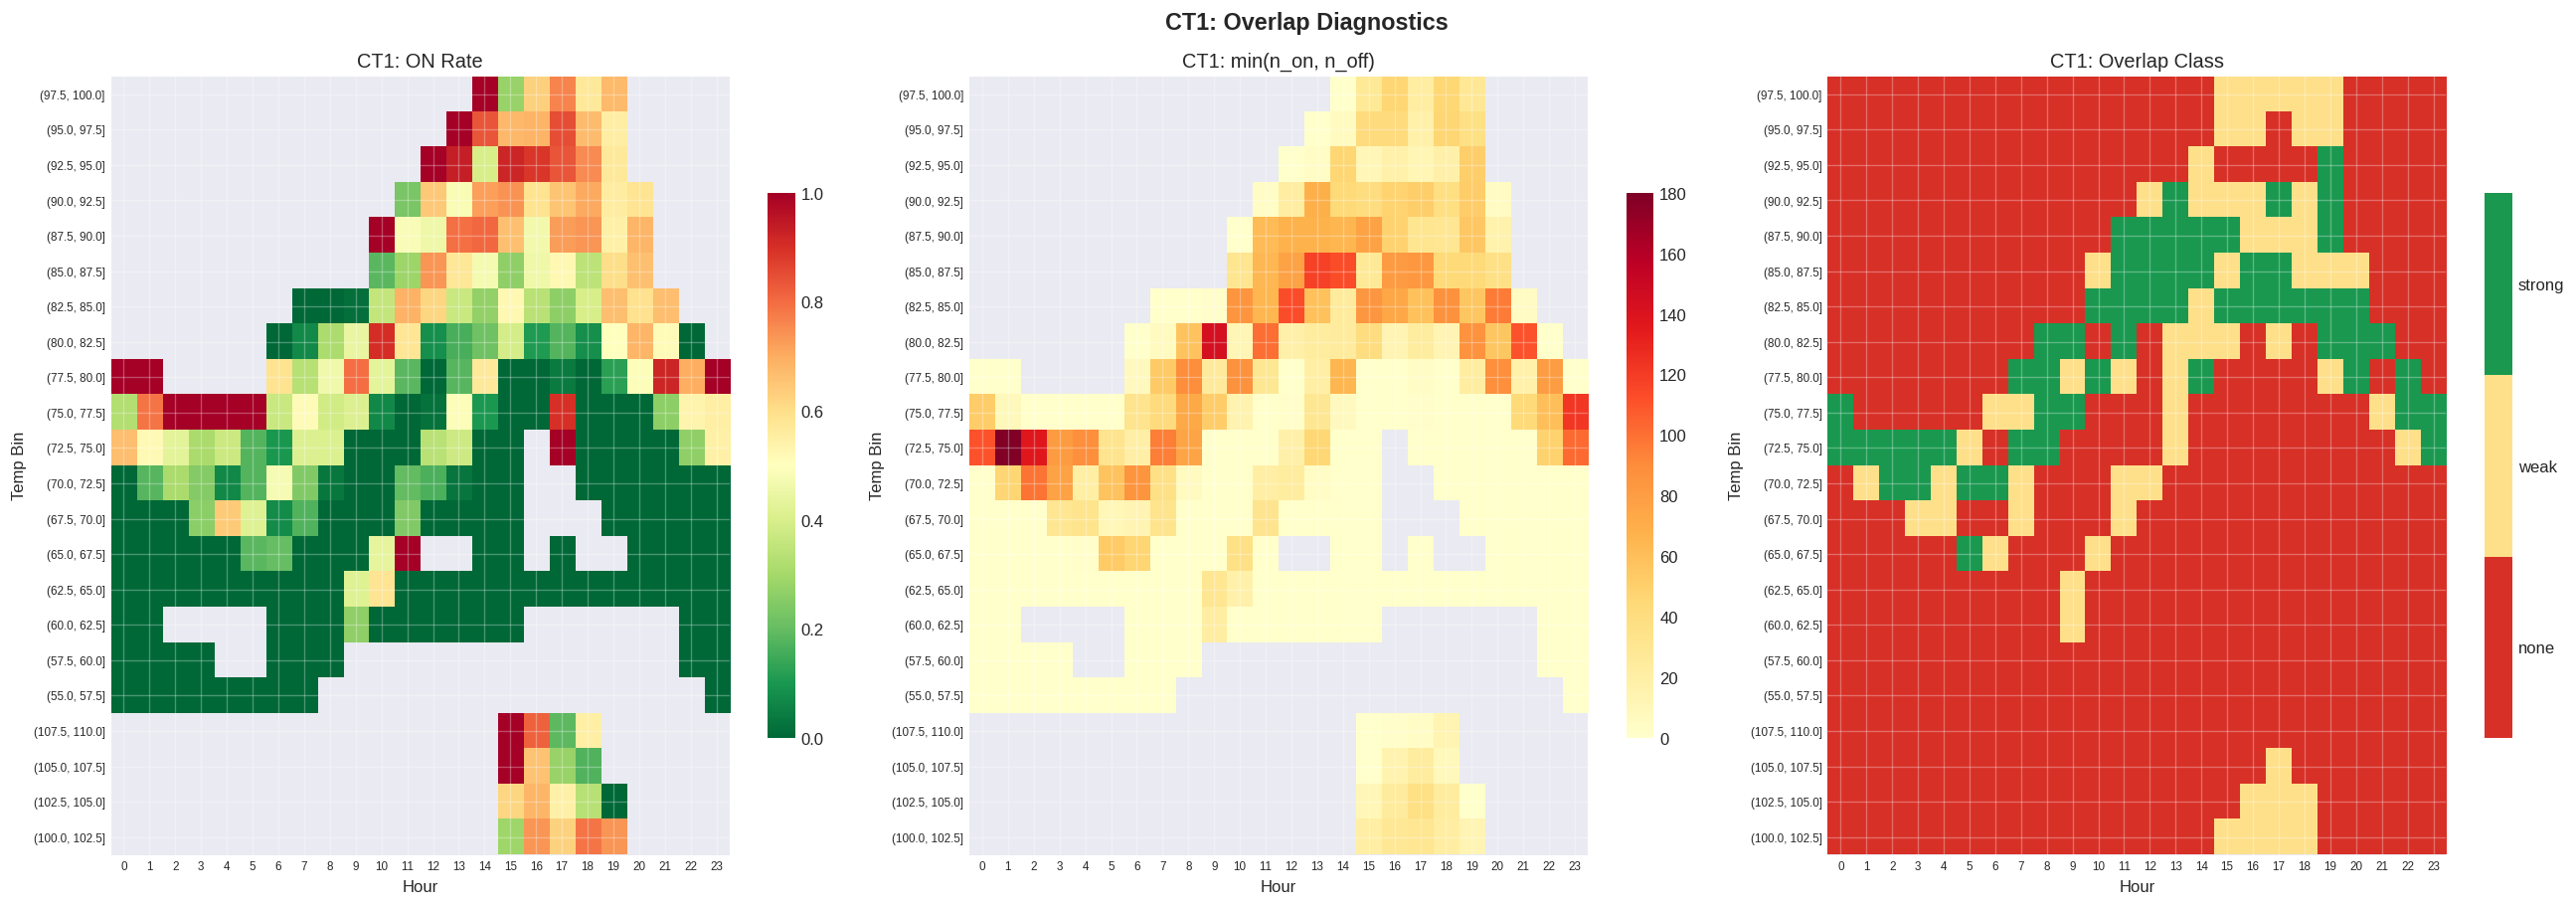

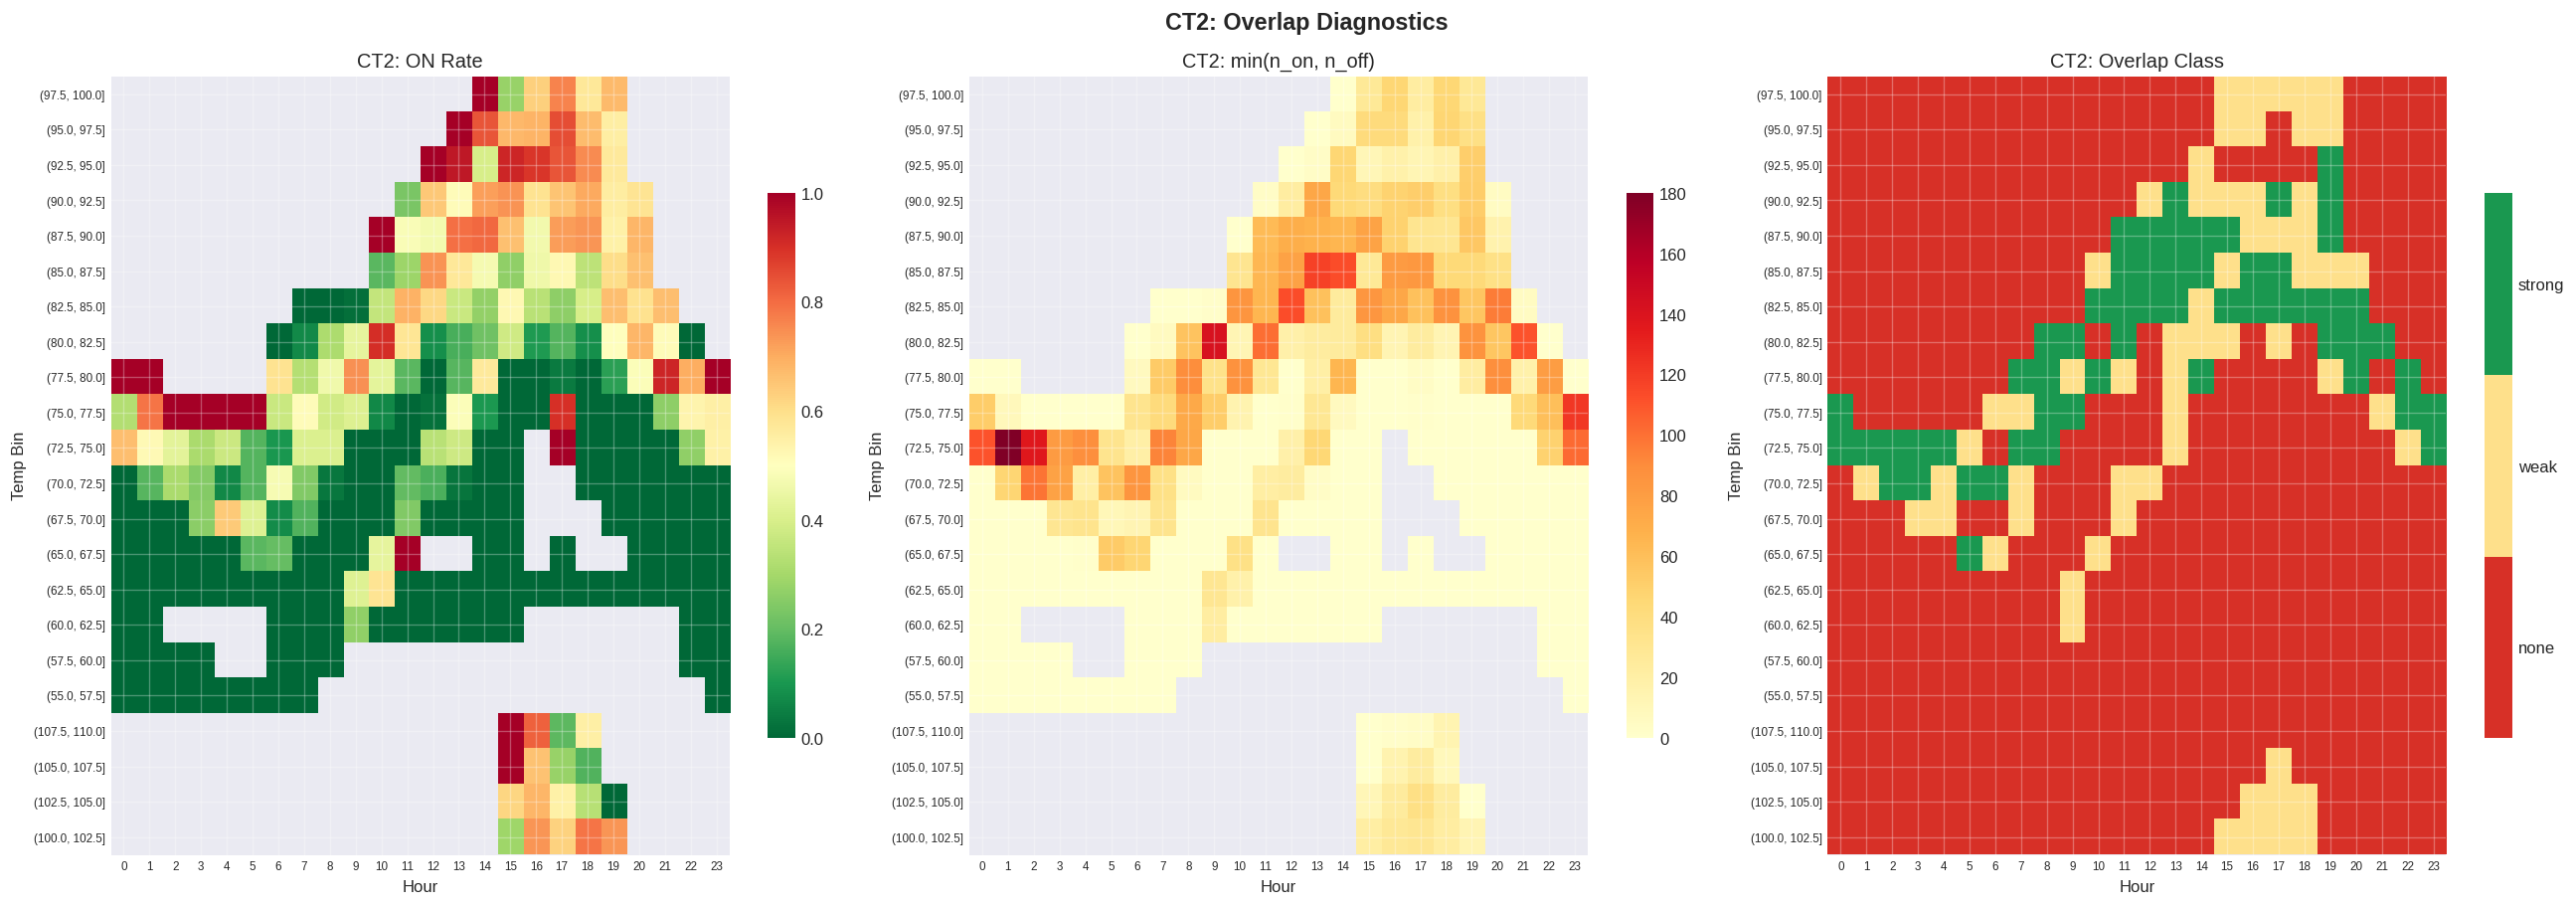


EFFECTS SUMMARY:
turbine spec overlap  ATE_MW  ci_lo  ci_hi  uplift_85F  uplift_90F  uplift_95F     R2  N_train  N_report_strong  strong_frac
    CT1    A  strong  1.1185 0.9935 1.1653      1.2251      1.3703      1.5011 0.9640    33108            12248       0.3699
    CT2    A  strong  1.3285 1.2209 1.4578      1.5314      1.7303      1.8926 0.9400    33133            12258       0.3700


In [14]:
# ============================================================================
# SAVE OLS OUTPUTS (original)
# ============================================================================
effects_rows = []
for ct_label, res in all_results.items():
    effects_rows.append({
        'turbine': ct_label, 'spec': SPEC,
        'overlap': 'strong' if OVL_ON else 'off',
        'ATE_MW': res['ate'], 'ci_lo': res['ci_lo'], 'ci_hi': res['ci_hi'],
        'uplift_85F': res['u85'], 'uplift_90F': res['u90'], 'uplift_95F': res['u95'],
        'R2': res['model'].rsquared,
        'N_train': len(res['df_train']),
        'N_report_strong': len(res['df_report_strong']),
        'strong_frac': res['ovl_meta']['strong_frac'] if res['ovl_meta'] else 1.0,
    })
    if res['ovl_meta']:
        m = res['ovl_meta']
        m['grid'].to_csv(f'{OUT}/overlap_grid_{ct_label}_{tag}.csv', index=False)
        m['summary'].to_csv(f'{OUT}/overlap_summary_{ct_label}_{tag}.csv', index=False)
        plot_overlap_heatmaps(m['grid'], ct_label, OUT)
    pd.DataFrame({'boot_ate_mw': res['boot_arr']}).to_csv(
        f'{OUT}/bootstrap_ate_{ct_label}_{tag}.csv', index=False)
    if res['curve']:
        temps, pe, clo, chi = res['curve']
        pd.DataFrame({'temp_f': temps, 'uplift_mw': pe, 'ci_lo': clo, 'ci_hi': chi,
        }).to_csv(f'{OUT}/bootstrap_curve_{ct_label}_{tag}.csv', index=False)

effects_df = pd.DataFrame(effects_rows)
effects_df.to_csv(f'{OUT}/effects_summary_{tag}.csv', index=False)
print('\nEFFECTS SUMMARY:')
print(effects_df.to_string(index=False))


### 5c. OLS Uplift Curve Plots

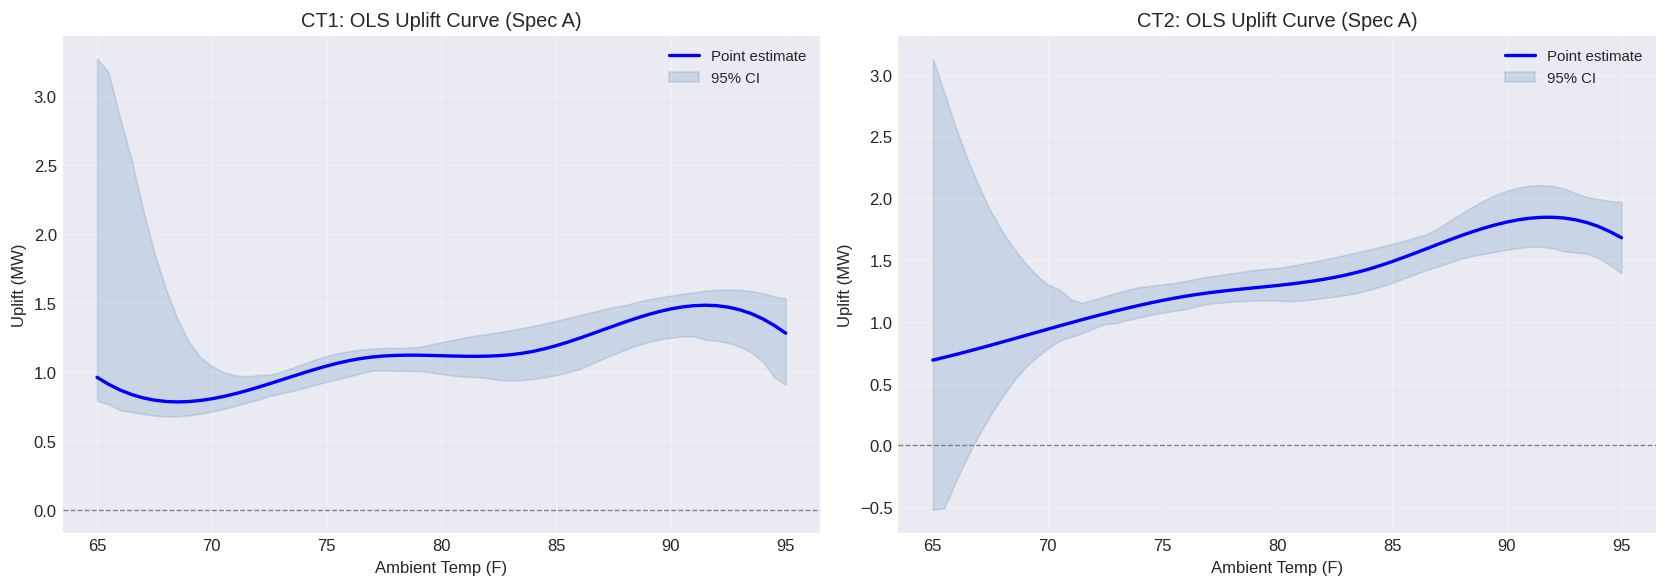

In [15]:
n_ct = len(all_results)
if n_ct > 0:
    fig, axes = plt.subplots(1, n_ct, figsize=(7*n_ct, 5), squeeze=False)
    for i, (ct_l, res) in enumerate(all_results.items()):
        ax = axes[0, i]
        if res['curve']:
            temps, pe, clo, chi = res['curve']
            ax.plot(temps, pe, 'b-', lw=2, label='Point estimate')
            ax.fill_between(temps, clo, chi, alpha=0.2, color='steelblue',
                            label=f'{int(CONFIG["bootstrap"]["ci_level"]*100)}% CI')
        ax.axhline(0, color='grey', ls='--', lw=0.8)
        ax.set_xlabel('Ambient Temp (F)'); ax.set_ylabel('Uplift (MW)')
        ax.set_title(f'{ct_l}: OLS Uplift Curve (Spec {SPEC})')
        ax.legend(fontsize=9)
    plt.tight_layout()
    fig.savefig(f'{OUT}/uplift_curve_{tag}.png', dpi=150, bbox_inches='tight')
    plt.show()


---
---
## 7. OLS vs GBT — Fair Total-Effect Comparison (Power & Fuel)

**Design**: Same day-block split → same overlap strong mask → same features → Plugin ATE + AIPW ATE → bootstrap CI

Outcomes:
- `{ct}_power_mw` (power output)
- `{ct}_gas_fuel_flow_lbph` (fuel usage)

Models:
- OLS (Spec A / Spec B via `build_formula`)
- GBT (LightGBM S-learner, same X)


### 7a. Feature Builder (aligned OLS ↔ GBT)

In [16]:
import pandas as pd

# ============================================================================
# Build aligned feature sets for OLS and GBT
# ============================================================================

def get_feature_cols(ct_prefix, spec='A'):
    """Return list of X columns (no outcome, no D) aligned with OLS formula."""
    base = ['ambient_air_temp_f', 'ambient_rh_pct',
            f'{ct_prefix}_gas_supply_pressure_psi',
            f'{ct_prefix}_inlet_air_supply_pressure_psig',
            'demand'] # Add 'demand' here
    if spec == 'B':
        base += [f'{ct_prefix}_pcd', f'{ct_prefix}_t7_avg_temp']
    return base   # hour handled separately (categorical)


def get_outcome_cols(ct_prefix):
    """Return dict of outcome_name -> column_name."""
    return {
        'power': f'{ct_prefix}_power_mw',
        'fuel':  f'{ct_prefix}_gas_fuel_flow_lbph',
    }


def prepare_Xy_gbt(df, ct_prefix, spec='A'):
    """Build numeric feature matrix for GBT.
    Hour is one-hot encoded (matching OLS C(hour)).
    Returns (X_df, feature_names)."""
    x_cols = get_feature_cols(ct_prefix, spec)
    # Check availability
    available = [c for c in x_cols if c in df.columns]
    missing   = [c for c in x_cols if c not in df.columns]
    if missing:
        print(f'    WARNING: missing features for GBT Spec {spec}: {missing}')

    X = df[['D'] + available].copy()
    # One-hot for hour (same as OLS C(hour))
    hour_dummies = pd.get_dummies(df['hour'].astype(int), prefix='hour', drop_first=True)
    X = pd.concat([X, hour_dummies], axis=1)
    return X, list(X.columns)


print('Feature builder defined')

Feature builder defined


### 7b. Core Comparison Engine

In [17]:
# ============================================================================
# run_comparison: one turbine, one outcome, one spec -> OLS + GBT results
# ============================================================================

def run_comparison(df_prepared, ct_prefix, ct_label, outcome_name, y_col,
                   spec, ovl_cfg, cmp_cfg, seed=42):
    """Run fair OLS-vs-GBT comparison.

    Returns dict with keys: ate_rows, uplift_rows, test_df, or None on failure.
    """
    np.random.seed(seed)

    # --- Check y_col exists ---
    if y_col not in df_prepared.columns:
        print(f'  {ct_label}/{outcome_name}: {y_col} not found, SKIPPING')
        return None

    # --- Needed columns (superset for both models) ---
    x_base = get_feature_cols(ct_prefix, spec)
    available_x = [c for c in x_base if c in df_prepared.columns]
    needed = [y_col, 'D', 'hour', 'day', 'ambient_air_temp_f'] + available_x
    df_clean = df_prepared.dropna(subset=[c for c in needed if c in df_prepared.columns]).copy()
    if len(df_clean) < 200:
        print(f'  {ct_label}/{outcome_name}: too few rows ({len(df_clean)}), skipping')
        return None

    # --- Day-block split ---
    unique_days = np.array(sorted(df_clean['day'].unique()))
    n_test = max(1, int(len(unique_days) * cmp_cfg['test_days_frac']))
    test_days = np.random.choice(unique_days, size=n_test, replace=False)
    df_train = df_clean[~df_clean['day'].isin(test_days)].copy()
    df_test  = df_clean[ df_clean['day'].isin(test_days)].copy()

    # --- Overlap strong mask (on TRAIN only, then apply to TEST) ---
    if ovl_cfg['enabled']:
        _, ovl_meta_tr = apply_overlap_filter(df_train, ovl_cfg)
        grid, bins = ovl_meta_tr['grid'], ovl_meta_tr['bins']
        mask_te, tb_te = _build_strong_mask(df_test, grid, bins)
        df_test_strong = df_test[mask_te.values].copy()
        df_test_strong['temp_bin'] = tb_te[mask_te.values].values
    else:
        df_test_strong = df_test.copy()
        bw = ovl_cfg['temp_bin_width_F']
        bins_arr = np.arange(55, 110+bw, bw)
        df_test_strong['temp_bin'] = pd.cut(df_test_strong['ambient_air_temp_f'], bins=bins_arr)

    n_on_te  = int((df_test_strong['D']==1).sum())
    n_off_te = int((df_test_strong['D']==0).sum())
    print(f'  {ct_label}/{outcome_name} Spec{spec}: '
          f'train={len(df_train):,}  test_strong={len(df_test_strong):,} '
          f'(ON={n_on_te}, OFF={n_off_te})  test_days={n_test}')

    if len(df_test_strong) < 50 or n_on_te < 10 or n_off_te < 10:
        print(f'    Insufficient test strong data, skipping')
        return None

    # =====================================================================
    # FIT MODELS (both on df_train)
    # =====================================================================

    # --- OLS ---
    ols_y_col, ols_formula = build_formula(ct_prefix, spec, y_col=y_col)
    try:
        m_ols = smf.ols(ols_formula, data=df_train).fit()
    except Exception as e:
        print(f'    OLS fit failed: {e}'); return None

    # --- GBT ---
    X_train, feat_names = prepare_Xy_gbt(df_train, ct_prefix, spec)
    X_train = X_train.reindex(df_train.index)
    y_train = df_train[y_col]
    mask_ok = X_train.notna().all(axis=1) & y_train.notna()
    X_train, y_train = X_train[mask_ok], y_train[mask_ok]

    m_gbt = LGBMRegressor(**cmp_cfg['lgbm_params'])
    m_gbt.fit(X_train.values, y_train.values)
    m_gbt._feat_names = feat_names

    # --- Propensity model (for AIPW) ---
    prop_features = ['ambient_air_temp_f'] + [f'hour_{h}' for h in range(1,24)]
    prop_features = [c for c in prop_features if c in X_train.columns]
    if len(prop_features) < 2:
        prop_features = ['ambient_air_temp_f', 'ambient_rh_pct']
        prop_features = [c for c in prop_features if c in df_train.columns]
    X_prop = df_train[prop_features].dropna()
    y_prop = df_train.loc[X_prop.index, 'D']
    m_prop = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
    m_prop.fit(X_prop.values, y_prop.values)
    m_prop._features = prop_features

    # =====================================================================
    # PREDICT ON TEST STRONG
    # =====================================================================
    ts = df_test_strong.copy()

    # --- OLS counterfactual ---
    ts_on = ts.copy(); ts_on['D'] = 1.0
    ts_off = ts.copy(); ts_off['D'] = 0.0
    ts['m1_ols'] = m_ols.predict(ts_on)
    ts['m0_ols'] = m_ols.predict(ts_off)
    ts['tau_ols'] = ts['m1_ols'] - ts['m0_ols']

    # --- GBT counterfactual ---
    X_te, _ = prepare_Xy_gbt(ts, ct_prefix, spec)
    # Align columns
    for c in feat_names:
        if c not in X_te.columns:
            X_te[c] = 0
    X_te = X_te[feat_names]

    X_te_1 = X_te.copy(); X_te_1['D'] = 1.0
    X_te_0 = X_te.copy(); X_te_0['D'] = 0.0
    ts['m1_gbt'] = m_gbt.predict(X_te_1[feat_names].values)
    ts['m0_gbt'] = m_gbt.predict(X_te_0[feat_names].values)
    ts['tau_gbt'] = ts['m1_gbt'] - ts['m0_gbt']

    # --- Propensity + AIPW ---
    X_prop_te = ts[m_prop._features].copy()
    for c in m_prop._features:
        if c not in X_prop_te.columns:
            X_prop_te[c] = 0
    e_hat = m_prop.predict_proba(X_prop_te[m_prop._features].values)[:, 1]
    clip_lo, clip_hi = cmp_cfg['propensity_clip']
    e_hat = np.clip(e_hat, clip_lo, clip_hi)
    ts['e_hat'] = e_hat

    Y = ts[y_col].values
    D = ts['D'].values
    for mdl_tag in ['ols', 'gbt']:
        m1 = ts[f'm1_{mdl_tag}'].values
        m0 = ts[f'm0_{mdl_tag}'].values
        tau = ts[f'tau_{mdl_tag}'].values
        psi = tau + D*(Y - m1)/e_hat - (1-D)*(Y - m0)/(1-e_hat)
        ts[f'psi_{mdl_tag}'] = psi

    # --- Factual prediction metrics ---
    yhat_ols = np.where(D==1, ts['m1_ols'].values, ts['m0_ols'].values)
    yhat_gbt = np.where(D==1, ts['m1_gbt'].values, ts['m0_gbt'].values)
    rmse_ols = np.sqrt(mean_squared_error(Y, yhat_ols))
    rmse_gbt = np.sqrt(mean_squared_error(Y, yhat_gbt))
    r2_ols   = r2_score(Y, yhat_ols)
    r2_gbt   = r2_score(Y, yhat_gbt)

    # =====================================================================
    # BOOTSTRAP CI (fast: resample days, take mean of pre-computed scores)
    # =====================================================================
    n_boot = cmp_cfg['boot_n']
    alpha  = 1 - cmp_cfg['boot_ci']
    days_te = ts['day'].unique()

    boot_results = {k: [] for k in ['tau_ols','tau_gbt','psi_ols','psi_gbt']}
    for b in range(n_boot):
        bd = np.random.choice(days_te, size=len(days_te), replace=True)
        idx = ts['day'].isin(bd)
        if idx.sum() < 20: continue
        for k in boot_results:
            boot_results[k].append(float(ts.loc[idx, k].mean()))

    def ci(arr):
        arr = np.array(arr)
        return np.percentile(arr, 100*alpha/2), np.percentile(arr, 100*(1-alpha/2))

    # =====================================================================
    # ASSEMBLE ATE ROWS
    # =====================================================================
    ate_rows = []
    for mdl_tag, mdl_name in [('ols','OLS'),('gbt','GBT')]:
        # Plugin
        ate_val = float(ts[f'tau_{mdl_tag}'].mean())
        lo, hi = ci(boot_results[f'tau_{mdl_tag}'])
        ate_rows.append({
            'turbine': ct_label, 'outcome': outcome_name, 'model': mdl_name,
            'spec': spec, 'estimator': 'plugin',
            'ate': ate_val, 'ci_lo': lo, 'ci_hi': hi,
            'rmse_test': rmse_ols if mdl_tag=='ols' else rmse_gbt,
            'r2_test':   r2_ols   if mdl_tag=='ols' else r2_gbt,
            'n_test': len(ts), 'n_days_test': len(days_te),
            'support_note': 'strong' if ovl_cfg['enabled'] else 'full',
        })
        # AIPW
        ate_aipw = float(ts[f'psi_{mdl_tag}'].mean())
        lo_a, hi_a = ci(boot_results[f'psi_{mdl_tag}'])
        ate_rows.append({
            'turbine': ct_label, 'outcome': outcome_name, 'model': mdl_name,
            'spec': spec, 'estimator': 'aipw',
            'ate': ate_aipw, 'ci_lo': lo_a, 'ci_hi': hi_a,
            'rmse_test': np.nan, 'r2_test': np.nan,
            'n_test': len(ts), 'n_days_test': len(days_te),
            'support_note': 'strong' if ovl_cfg['enabled'] else 'full',
        })

    # =====================================================================
    # UPLIFT BY TEMP BIN
    # =====================================================================
    uplift_rows = []
    for tb, grp in ts.groupby('temp_bin', observed=True):
        n_on_g  = int((grp['D']==1).sum())
        n_off_g = int((grp['D']==0).sum())
        support_ok = (n_on_g >= 10 and n_off_g >= 10)
        for mdl_tag, mdl_name in [('ols','OLS'),('gbt','GBT')]:
            uplift_rows.append({
                'turbine': ct_label, 'outcome': outcome_name,
                'model': mdl_name, 'spec': spec,
                'temp_bin': str(tb),
                'uplift_mean': float(grp[f'tau_{mdl_tag}'].mean()),
                'n_total': len(grp), 'n_on': n_on_g, 'n_off': n_off_g,
                'support_ok': support_ok,
            })

    return {
        'ate_rows': ate_rows,
        'uplift_rows': uplift_rows,
        'test_df': ts,
        'rmse_ols': rmse_ols, 'rmse_gbt': rmse_gbt,
        'r2_ols': r2_ols, 'r2_gbt': r2_gbt,
    }


print('run_comparison() defined')


run_comparison() defined


### 7c. Execute Comparison (all turbines × outcomes × specs)

In [18]:
import pandas as pd

# ============================================================================
# RUN ALL COMPARISONS
# ============================================================================
CMP_OUT = os.path.join(OUT, 'compare_ols_gbt_total_effect')
os.makedirs(CMP_OUT, exist_ok=True)

all_ate_rows    = []
all_uplift_rows = []
all_test_dfs    = {}

# Corrected run_comparison function with the fix
def run_comparison(df_prepared, ct_prefix, ct_label, outcome_name, y_col,
                   spec, ovl_cfg, cmp_cfg, seed=42):
    """Run fair OLS-vs-GBT comparison.

    Returns dict with keys: ate_rows, uplift_rows, test_df, or None on failure.
    """
    np.random.seed(seed)

    # --- Check y_col exists ---
    if y_col not in df_prepared.columns:
        print(f'  {ct_label}/{outcome_name}: {y_col} not found, SKIPPING')
        return None

    # --- Needed columns (superset for both models) ---
    x_base = get_feature_cols(ct_prefix, spec)
    available_x = [c for c in x_base if c in df_prepared.columns]
    needed = [y_col, 'D', 'hour', 'day', 'ambient_air_temp_f'] + available_x
    df_clean = df_prepared.dropna(subset=[c for c in needed if c in df_prepared.columns]).copy()
    if len(df_clean) < 200:
        print(f'  {ct_label}/{outcome_name}: too few rows ({len(df_clean)}), skipping')
        return None

    # --- Day-block split ---
    unique_days = np.array(sorted(df_clean['day'].unique()))
    n_test = max(1, int(len(unique_days) * cmp_cfg['test_days_frac']))
    test_days = np.random.choice(unique_days, size=n_test, replace=False)
    df_train = df_clean[~df_clean['day'].isin(test_days)].copy()
    df_test  = df_clean[ df_clean['day'].isin(test_days)].copy()

    # --- Overlap strong mask (on TRAIN only, then apply to TEST) ---
    if ovl_cfg['enabled']:
        _, ovl_meta_tr = apply_overlap_filter(df_train, ovl_cfg)
        grid, bins = ovl_meta_tr['grid'], ovl_meta_tr['bins']
        mask_te, tb_te = _build_strong_mask(df_test, grid, bins)
        df_test_strong = df_test[mask_te.values].copy()
        df_test_strong['temp_bin'] = tb_te[mask_te.values].values
    else:
        df_test_strong = df_test.copy()
        bw = ovl_cfg['temp_bin_width_F']
        bins_arr = np.arange(55, 110+bw, bw)
        df_test_strong['temp_bin'] = pd.cut(df_test_strong['ambient_air_temp_f'], bins=bins_arr)

    n_on_te  = int((df_test_strong['D']==1).sum())
    n_off_te = int((df_test_strong['D']==0).sum())
    print(f'  {ct_label}/{outcome_name} Spec{spec}: '
          f'train={len(df_train):,}  test_strong={len(df_test_strong):,} '
          f'(ON={n_on_te}, OFF={n_off_te})  test_days={n_test}')

    if len(df_test_strong) < 50 or n_on_te < 10 or n_off_te < 10:
        print(f'    Insufficient test strong data, skipping')
        return None

    # =====================================================================
    # FIT MODELS (both on df_train)
    # =====================================================================

    # --- OLS ---
    ols_y_col, ols_formula = build_formula(ct_prefix, spec, y_col=y_col)
    try:
        m_ols = smf.ols(ols_formula, data=df_train).fit()
    except Exception as e:
        print(f'    OLS fit failed: {e}'); return None

    # --- GBT ---
    X_train_gbt, feat_names = prepare_Xy_gbt(df_train, ct_prefix, spec)
    X_train_gbt = X_train_gbt.reindex(df_train.index)
    y_train_gbt = df_train[y_col]
    mask_ok_gbt = X_train_gbt.notna().all(axis=1) & y_train_gbt.notna()
    X_train_gbt, y_train_gbt = X_train_gbt[mask_ok_gbt], y_train_gbt[mask_ok_gbt]

    m_gbt = LGBMRegressor(**cmp_cfg['lgbm_params'])
    m_gbt.fit(X_train_gbt.values, y_train_gbt.values)
    m_gbt._feat_names = feat_names

    # --- Propensity model (for AIPW) ---
    # X_train_gbt already contains the one-hot encoded hour features and 'D'
    prop_features_candidate = ['ambient_air_temp_f'] + [f'hour_{h}' for h in range(1,24)]
    prop_features = [c for c in prop_features_candidate if c in X_train_gbt.columns]

    if len(prop_features) < 2:
        prop_features = ['ambient_air_temp_f', 'ambient_rh_pct']
        prop_features = [c for c in prop_features if c in X_train_gbt.columns] # Use X_train_gbt.columns here

    # Construct X_prop and y_prop from X_train_gbt
    X_prop = X_train_gbt[prop_features].copy()
    y_prop = X_train_gbt.loc[X_prop.index, 'D']

    m_prop = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
    m_prop.fit(X_prop.values, y_prop.values)
    m_prop._features = prop_features

    # =====================================================================
    # PREDICT ON TEST STRONG
    # =====================================================================
    ts = df_test_strong.copy()

    # --- OLS counterfactual ---
    ts_on = ts.copy(); ts_on['D'] = 1.0
    ts_off = ts.copy(); ts_off['D'] = 0.0
    ts['m1_ols'] = m_ols.predict(ts_on)
    ts['m0_ols'] = m_ols.predict(ts_off)
    ts['tau_ols'] = ts['m1_ols'] - ts['m0_ols']

    # --- GBT counterfactual ---
    X_te, _ = prepare_Xy_gbt(ts, ct_prefix, spec)
    # Align columns
    for c in feat_names:
        if c not in X_te.columns:
            X_te[c] = 0
    X_te = X_te[feat_names]

    X_te_1 = X_te.copy(); X_te_1['D'] = 1.0
    X_te_0 = X_te.copy(); X_te_0['D'] = 0.0
    ts['m1_gbt'] = m_gbt.predict(X_te_1[feat_names].values)
    ts['m0_gbt'] = m_gbt.predict(X_te_0[feat_names].values)
    ts['tau_gbt'] = ts['m1_gbt'] - ts['m0_gbt']

    # --- Propensity + AIPW ---
    # Generate one-hot encoded hour columns for the test set
    hour_dummies_ts = pd.get_dummies(ts['hour'].astype(int), prefix='hour')

    # Prepare a DataFrame to hold all propensity features for the test set,
    # ensuring all features that m_prop._features expects are present.
    X_prop_te = pd.DataFrame(index=ts.index)

    for feature in m_prop._features:
        if feature.startswith('hour_'):
            # Populate hour dummy features, filling with 0 if an hour is missing in test data
            if feature in hour_dummies_ts.columns:
                X_prop_te[feature] = hour_dummies_ts[feature]
            else:
                X_prop_te[feature] = 0
        else:
            # Populate other features directly from 'ts'
            X_prop_te[feature] = ts[feature]

    # Predict propensity scores
    e_hat = m_prop.predict_proba(X_prop_te.values)[:, 1]
    clip_lo, clip_hi = cmp_cfg['propensity_clip']
    e_hat = np.clip(e_hat, clip_lo, clip_hi)
    ts['e_hat'] = e_hat

    Y = ts[y_col].values
    D = ts['D'].values
    for mdl_tag in ['ols', 'gbt']:
        m1 = ts[f'm1_{mdl_tag}'].values
        m0 = ts[f'm0_{mdl_tag}'].values
        tau = ts[f'tau_{mdl_tag}'].values
        psi = tau + D*(Y - m1)/e_hat - (1-D)*(Y - m0)/(1-e_hat)
        ts[f'psi_{mdl_tag}'] = psi

    # --- Factual prediction metrics ---
    yhat_ols = np.where(D==1, ts['m1_ols'].values, ts['m0_ols'].values)
    yhat_gbt = np.where(D==1, ts['m1_gbt'].values, ts['m0_gbt'].values)
    rmse_ols = np.sqrt(mean_squared_error(Y, yhat_ols))
    rmse_gbt = np.sqrt(mean_squared_error(Y, yhat_gbt))
    r2_ols   = r2_score(Y, yhat_ols)
    r2_gbt   = r2_score(Y, yhat_gbt)

    # =====================================================================
    # BOOTSTRAP CI (fast: resample days, take mean of pre-computed scores)
    # =====================================================================
    n_boot = cmp_cfg['boot_n']
    alpha  = 1 - cmp_cfg['boot_ci']
    days_te = ts['day'].unique()

    boot_results = {k: [] for k in ['tau_ols','tau_gbt','psi_ols','psi_gbt']}
    for b in range(n_boot):
        bd = np.random.choice(days_te, size=len(days_te), replace=True)
        idx = ts['day'].isin(bd)
        if idx.sum() < 20: continue
        for k in boot_results:
            boot_results[k].append(float(ts.loc[idx, k].mean()))

    def ci(arr):
        arr = np.array(arr)
        return np.percentile(arr, 100*alpha/2), np.percentile(arr, 100*(1-alpha/2))

    # =====================================================================
    # ASSEMBLE ATE ROWS
    # =====================================================================
    ate_rows = []
    for mdl_tag, mdl_name in [('ols','OLS'),('gbt','GBT')]:
        # Plugin
        ate_val = float(ts[f'tau_{mdl_tag}'].mean())
        lo, hi = ci(boot_results[f'tau_{mdl_tag}']) if boot_results[f'tau_{mdl_tag}'] else (np.nan, np.nan)
        ate_rows.append({
            'turbine': ct_label, 'outcome': outcome_name, 'model': mdl_name,
            'spec': spec, 'estimator': 'plugin',
            'ate': ate_val, 'ci_lo': lo, 'ci_hi': hi,
            'rmse_test': rmse_ols if mdl_tag=='ols' else rmse_gbt,
            'r2_test':   r2_ols   if mdl_tag=='ols' else r2_gbt,
            'n_test': len(ts), 'n_days_test': len(days_te),
            'support_note': 'strong' if ovl_cfg['enabled'] else 'full',
        })
        # AIPW
        ate_aipw = float(ts[f'psi_{mdl_tag}'].mean())
        lo_a, hi_a = ci(boot_results[f'psi_{mdl_tag}']) if boot_results[f'psi_{mdl_tag}'] else (np.nan, np.nan)
        ate_rows.append({
            'turbine': ct_label, 'outcome': outcome_name, 'model': mdl_name,
            'spec': spec, 'estimator': 'aipw',
            'ate': ate_aipw, 'ci_lo': lo_a, 'ci_hi': hi_a,
            'rmse_test': np.nan, 'r2_test': np.nan,
            'n_test': len(ts), 'n_days_test': len(days_te),
            'support_note': 'strong' if ovl_cfg['enabled'] else 'full',
        })

    # =====================================================================
    # UPLIFT BY TEMP BIN
    # =====================================================================
    uplift_rows = []
    for tb, grp in ts.groupby('temp_bin', observed=True):
        n_on_g  = int((grp['D']==1).sum())
        n_off_g = int((grp['D']==0).sum())
        support_ok = (n_on_g >= 10 and n_off_g >= 10)
        for mdl_tag, mdl_name in [('ols','OLS'),('gbt','GBT')]:
            uplift_rows.append({
                'turbine': ct_label, 'outcome': outcome_name,
                'model': mdl_name, 'spec': spec,
                'temp_bin': str(tb),
                'uplift_mean': float(grp[f'tau_{mdl_tag}'].mean()),
                'n_total': len(grp), 'n_on': n_on_g, 'n_off': n_off_g,
                'support_ok': support_ok,
            })

    return {
        'ate_rows': ate_rows,
        'uplift_rows': uplift_rows,
        'test_df': ts,
        'rmse_ols': rmse_ols, 'rmse_gbt': rmse_gbt,
        'r2_ols': r2_ols, 'r2_gbt': r2_gbt,
    }


for ct_prefix, ct_label, df_raw in [('ct1','CT1',df_ct1), ('ct2','CT2',df_ct2)]:
    print(f'\n{'='*72}\n{ct_label} — OLS vs GBT comparison\n{'='*72}')

    # Prepare data once (shared by all outcomes/specs)
    df_prep = prepare_df(df_raw, ct_label,
                         CONFIG['data']['train_temp_range_F'],
                         CONFIG['treatment'])

    outcomes = get_outcome_cols(ct_prefix)

    for spec in ['A']:#, 'B']:
        for outcome_name, y_col in outcomes.items():
            print(f'\n--- {ct_label} / {outcome_name} / Spec {spec} ---')
            res = run_comparison(
                df_prep, ct_prefix, ct_label, outcome_name, y_col,
                spec, CONFIG['overlap'], CONFIG['compare'],
                seed=CONFIG['seed'])
            if res is None:
                continue
            all_ate_rows.extend(res['ate_rows'])
            all_uplift_rows.extend(res['uplift_rows'])
            key = f'{ct_label}_{outcome_name}_{spec}'
            all_test_dfs[key] = res['test_df']
            print(f'    RMSE: OLS={res["rmse_ols"]:.4f}  GBT={res["rmse_gbt"]:.4f}')
            print(f'    R2:   OLS={res["r2_ols"]:.4f}  GBT={res["r2_gbt"]:.4f}')

print('\n' + '='*72 + '\nAll comparisons complete\n' + '='*72)


CT1 — OLS vs GBT comparison
  CT1: treatment 'full_vs_off' -> dropped 1,972 partial rows
  CT1: decontamination (+/-10min) -> dropped 254 rows
  CT1: temp [55-110F] -> 33,108 rows

--- CT1 / power / Spec A ---
  CT1/power SpecA: train=27,476  test_strong=1,072 (ON=871, OFF=201)  test_days=5
    RMSE: OLS=0.1205  GBT=0.1041
    R2:   OLS=0.9527  GBT=0.9647

--- CT1 / fuel / Spec A ---
  CT1/fuel SpecA: train=27,476  test_strong=1,072 (ON=871, OFF=201)  test_days=5
    RMSE: OLS=51.1416  GBT=50.6288
    R2:   OLS=0.9223  GBT=0.9239

CT2 — OLS vs GBT comparison
  CT2: treatment 'full_vs_off' -> dropped 10,743 partial rows
  CT2: decontamination (+/-10min) -> dropped 250 rows
  CT2: temp [55-110F] -> 33,133 rows

--- CT2 / power / Spec A ---
  CT2/power SpecA: train=28,415  test_strong=910 (ON=397, OFF=513)  test_days=5
    RMSE: OLS=0.1641  GBT=0.1902
    R2:   OLS=0.9416  GBT=0.9216

--- CT2 / fuel / Spec A ---
  CT2/fuel SpecA: train=28,415  test_strong=910 (ON=397, OFF=513)  test_days

### 7d. Save Comparison Outputs

In [19]:
# ============================================================================
# SAVE: ate_summary.csv, uplift_by_tempbin.csv, test_rows
# ============================================================================

# 1) ATE Summary
ate_df = pd.DataFrame(all_ate_rows)
ate_df.to_csv(f'{CMP_OUT}/ate_summary.csv', index=False)
print('ate_summary.csv:')
print(ate_df.to_string(index=False))

# 2) Uplift by temp bin
uplift_df = pd.DataFrame(all_uplift_rows)
uplift_df.to_csv(f'{CMP_OUT}/uplift_by_tempbin.csv', index=False)
print(f'\nuplift_by_tempbin.csv: {len(uplift_df)} rows')

# 3) Test rows (one CSV per turbine/outcome/spec)
for key, tdf in all_test_dfs.items():
    cols_save = ['TimeStamp', 'day', 'hour', 'D', 'ambient_air_temp_f',
                 'temp_bin', 'm0_ols', 'm1_ols', 'tau_ols', 'psi_ols',
                 'm0_gbt', 'm1_gbt', 'tau_gbt', 'psi_gbt', 'e_hat']
    # Add outcome column
    y_candidates = [c for c in tdf.columns if c.endswith('_power_mw') or c.endswith('_flow_lbph')]
    cols_save = [c for c in cols_save + y_candidates if c in tdf.columns]
    tdf[cols_save].to_csv(f'{CMP_OUT}/test_rows_{key}.csv', index=False)

print(f'\nAll files saved to {CMP_OUT}/')


ate_summary.csv:
turbine outcome model spec estimator      ate    ci_lo    ci_hi  rmse_test  r2_test  n_test  n_days_test support_note
    CT1   power   OLS    A    plugin   1.2056   1.1715   1.2532     0.1205   0.9527    1072            5       strong
    CT1   power   OLS    A      aipw   1.2505   1.0971   1.3768        NaN      NaN    1072            5       strong
    CT1   power   GBT    A    plugin   1.2091   1.1323   1.2804     0.1041   0.9647    1072            5       strong
    CT1   power   GBT    A      aipw   1.2910   1.0688   1.4347        NaN      NaN    1072            5       strong
    CT1    fuel   OLS    A    plugin 382.4308 372.7532 395.9094    51.1416   0.9223    1072            5       strong
    CT1    fuel   OLS    A      aipw 405.7656 340.3075 458.2451        NaN      NaN    1072            5       strong
    CT1    fuel   GBT    A    plugin 379.1261 354.9584 402.8535    50.6288   0.9239    1072            5       strong
    CT1    fuel   GBT    A      aipw 40

### 7e. Comparison Plots

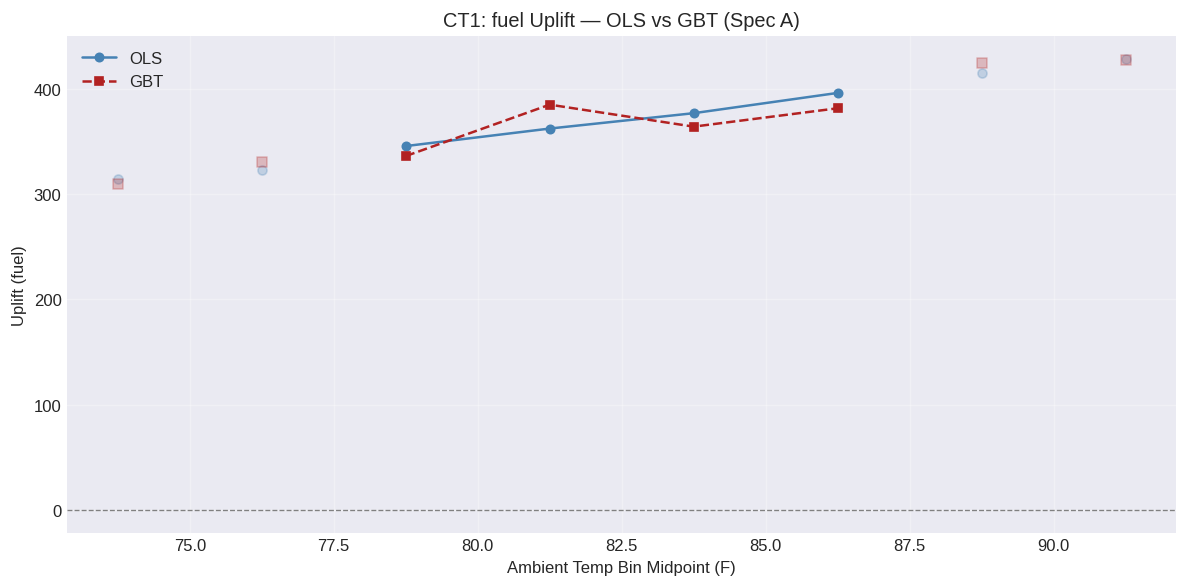

  Saved uplift_vs_tempbin_CT1_fuel_A.png


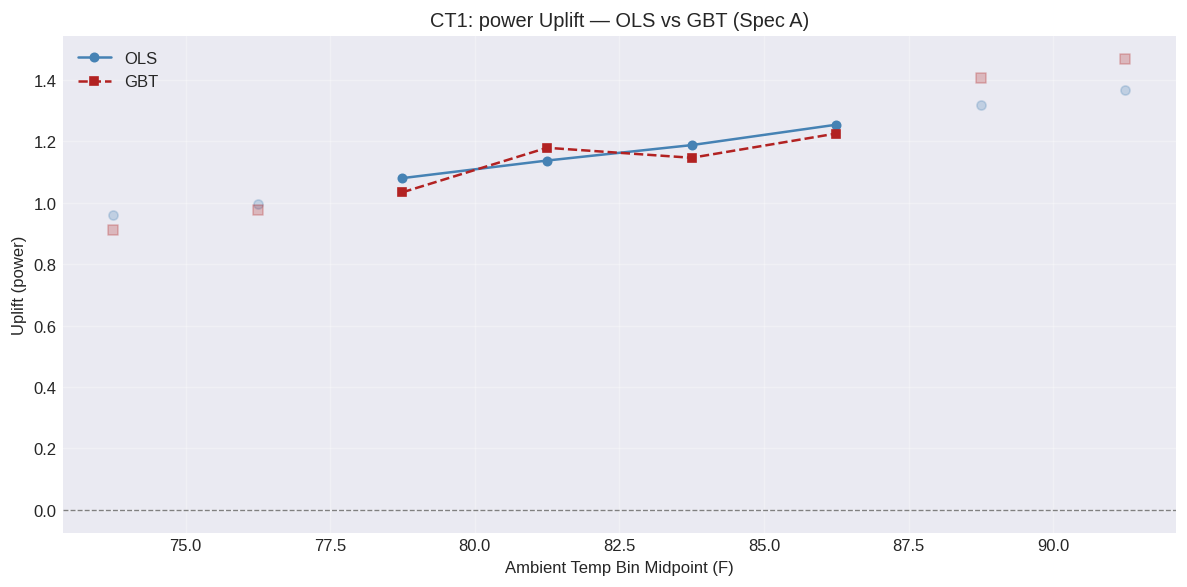

  Saved uplift_vs_tempbin_CT1_power_A.png


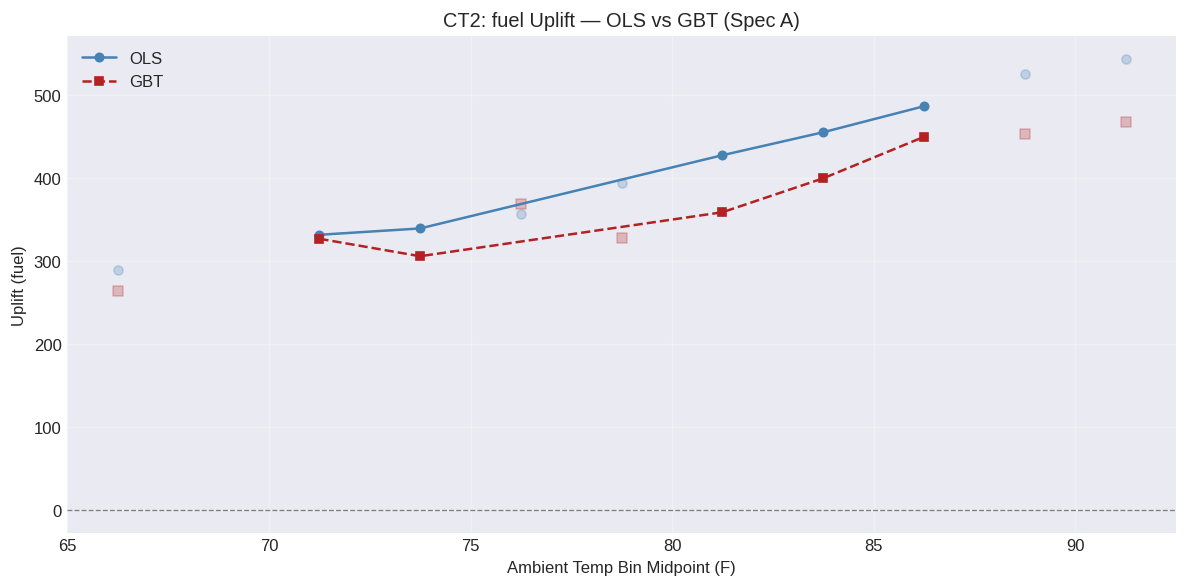

  Saved uplift_vs_tempbin_CT2_fuel_A.png


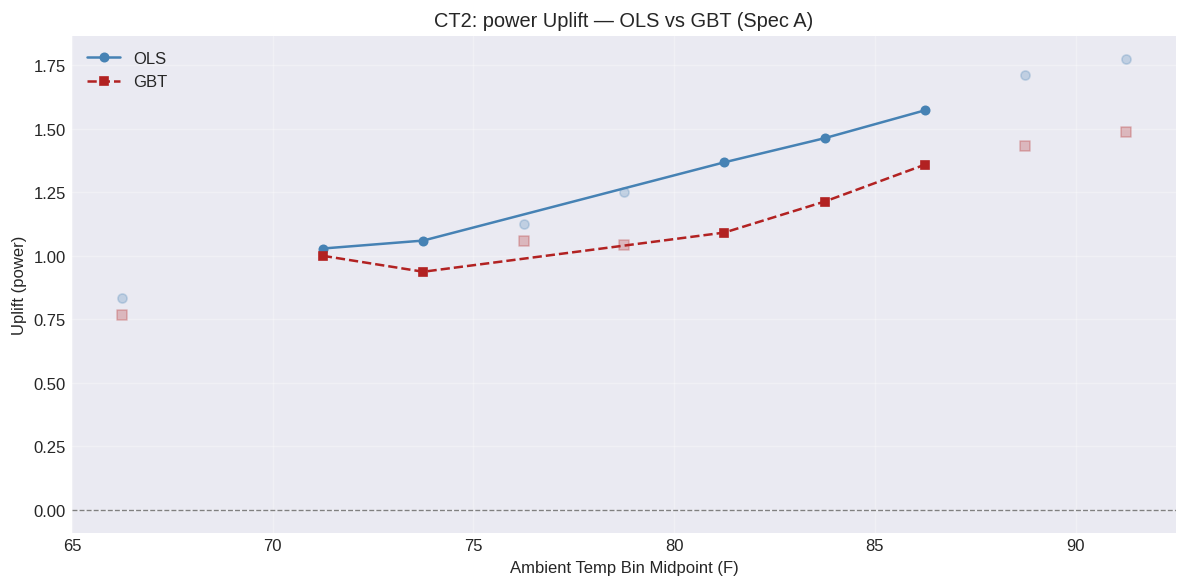

  Saved uplift_vs_tempbin_CT2_power_A.png


In [20]:
# ============================================================================
# PLOT: Uplift vs Temp Bin (OLS vs GBT, per turbine/outcome/spec)
# ============================================================================

# Get unique combos
if len(uplift_df) > 0:
    combos = uplift_df.groupby(['turbine','outcome','spec']).size().reset_index()[
        ['turbine','outcome','spec']].values.tolist()

    for turbine, outcome, spec in combos:
        sub = uplift_df[(uplift_df['turbine']==turbine) &
                        (uplift_df['outcome']==outcome) &
                        (uplift_df['spec']==spec)].copy()

        # Parse bin midpoints
        def bin_mid(s):
            try:
                s = str(s).strip('()[] ')
                parts = s.split(',')
                return (float(parts[0]) + float(parts[1])) / 2
            except:
                return np.nan
        sub['bin_mid'] = sub['temp_bin'].apply(bin_mid)
        sub = sub.dropna(subset=['bin_mid'])

        fig, ax = plt.subplots(figsize=(10, 5))
        for mdl_name, color, marker, ls in [('OLS','steelblue','o','-'),
                                              ('GBT','firebrick','s','--')]:
            m = sub[sub['model']==mdl_name].sort_values('bin_mid')
            ok  = m[m['support_ok']==True]
            nok = m[m['support_ok']==False]
            ax.plot(ok['bin_mid'], ok['uplift_mean'], marker=marker, color=color,
                    ls=ls, lw=1.5, ms=5, label=f'{mdl_name}')
            if len(nok) > 0:
                ax.scatter(nok['bin_mid'], nok['uplift_mean'], marker=marker,
                           color=color, alpha=0.25, s=30)

        ax.axhline(0, color='grey', ls='--', lw=0.8)
        ax.set_xlabel('Ambient Temp Bin Midpoint (F)')
        ax.set_ylabel(f'Uplift ({outcome})')
        ax.set_title(f'{turbine}: {outcome} Uplift — OLS vs GBT (Spec {spec})')
        ax.legend()
        plt.tight_layout()
        fname = f'uplift_vs_tempbin_{turbine}_{outcome}_{spec}.png'
        fig.savefig(f'{CMP_OUT}/{fname}', dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  Saved {fname}')
else:
    print('No uplift data to plot.')


### 7f. Results Summary

In [21]:
# ============================================================================
# RESULTS SUMMARY
# ============================================================================
print('='*80)
print('RESULTS SUMMARY: OLS vs GBT Total-Effect Comparison')
print('='*80)

if len(ate_df) > 0:
    # Plugin ATEs
    plugin = ate_df[ate_df['estimator']=='plugin'].copy()
    plugin['ate_str'] = plugin.apply(
        lambda r: f'{r["ate"]:+.4f} [{r["ci_lo"]:+.4f}, {r["ci_hi"]:+.4f}]', axis=1)
    summary = plugin.pivot_table(
        index=['turbine','outcome','spec'],
        columns='model',
        values='ate_str',
        aggfunc='first'
    )
    print('\n--- Plugin ATE (with 95% CI) ---')
    print(summary.to_string())

    # AIPW ATEs
    aipw = ate_df[ate_df['estimator']=='aipw'].copy()
    aipw['ate_str'] = aipw.apply(
        lambda r: f'{r["ate"]:+.4f} [{r["ci_lo"]:+.4f}, {r["ci_hi"]:+.4f}]', axis=1)
    summary_a = aipw.pivot_table(
        index=['turbine','outcome','spec'],
        columns='model',
        values='ate_str',
        aggfunc='first'
    )
    print('\n--- AIPW ATE (with 95% CI) ---')
    print(summary_a.to_string())

    # Test-set prediction quality
    pred = plugin[['turbine','outcome','spec','model','rmse_test','r2_test']].copy()
    print('\n--- Test-Set Prediction Quality ---')
    print(pred.to_string(index=False))

print(f'\n--- Output Files ---')
for f in sorted(os.listdir(CMP_OUT)):
    sz = os.path.getsize(os.path.join(CMP_OUT, f)) / 1024
    print(f'  {CMP_OUT}/{f:55s} {sz:7.1f} KB')


RESULTS SUMMARY: OLS vs GBT Total-Effect Comparison

--- Plugin ATE (with 95% CI) ---
model                                              GBT                               OLS
turbine outcome spec                                                                    
CT1     fuel    A     +379.1261 [+354.9584, +402.8535]  +382.4308 [+372.7532, +395.9094]
        power   A           +1.2091 [+1.1323, +1.2804]        +1.2056 [+1.1715, +1.2532]
CT2     fuel    A     +374.4483 [+331.3749, +407.9311]  +420.4961 [+374.1449, +467.0006]
        power   A           +1.1435 [+1.0229, +1.2372]        +1.3389 [+1.1767, +1.5065]

--- AIPW ATE (with 95% CI) ---
model                                              GBT                               OLS
turbine outcome spec                                                                    
CT1     fuel    A     +403.2773 [+309.9590, +457.3374]  +405.7656 [+340.3075, +458.2451]
        power   A           +1.2910 [+1.0688, +1.4347]        +1.2505 [+1.0971, +

---
## 8. Files Inventory

In [22]:
print('\nALL FILES SAVED:')
for root, dirs, files in os.walk(OUT):
    for f in sorted(files):
        fp = os.path.join(root, f)
        sz = os.path.getsize(fp) / 1024
        rel = os.path.relpath(fp, OUT)
        print(f'  {rel:65s} {sz:7.1f} KB')



ALL FILES SAVED:
  bootstrap_ate_CT1_specA_overlapON.csv                                 0.9 KB
  bootstrap_ate_CT2_specA_overlapON.csv                                 0.9 KB
  bootstrap_curve_CT1_specA_overlapON.csv                               3.7 KB
  bootstrap_curve_CT2_specA_overlapON.csv                               3.7 KB
  effects_summary_specA_overlapON.csv                                   0.5 KB
  overlap_grid_CT1_specA_overlapON.csv                                 22.8 KB
  overlap_grid_CT2_specA_overlapON.csv                                 22.8 KB
  overlap_heatmap_CT1.png                                             129.8 KB
  overlap_heatmap_CT2.png                                             130.3 KB
  overlap_summary_CT1_specA_overlapON.csv                               0.7 KB
  overlap_summary_CT2_specA_overlapON.csv                               0.7 KB
  uplift_curve_specA_overlapON.png                                    100.2 KB
  compare_ols_gbt_total_effect/ate